# Detekcija phishing email-ova
### Skupovi podataka: Enron (legitimni) · Nazario Phishing Corpus · IWSPA-AP  
### Modeli: Random Forest · XGBoost · GPT-4o-mini (zero-shot) · Fino podešeni DistilBERT

---
**Pregled pipeline-a:**
 1. Učitavanje sirovih podataka  ->  2. Čišćenje i predobrada  ->  3. Dedupliciranje  ->  4. Spajanje i označavanje   ->  5. EDA  ->  6. Inženjering karakteristika -> 7. Podela na train/test -> 8. Klasični ML -> 9. GPT zero-shot -> 10. Analiza grešaka GPT-a -> 11. Fino podešavanje DistilBERT-a -> 12. Poređenje

In [18]:
import os
import re
import email
import hashlib
import csv
import warnings
import random
from pathlib import Path

import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

BASE_DIR   = Path("/home/lukavr/Documents/SIAP/PhishingEmailDetection/project")
RAW_DIR    = BASE_DIR / "data" / "raw"
PROC_DIR   = BASE_DIR / "data" / "processed"
PROC_DIR.mkdir(parents=True, exist_ok=True)

ENRON_DIR  = RAW_DIR / "enron" / "maildir"
NAZARIO_CSV = RAW_DIR / "Nazario" / "Nazario.csv"
IWSPA_FH   = RAW_DIR / "IWSPA" / "IWSPA2.0_Training_Full_Header"
IWSPA_NH   = RAW_DIR / "IWSPA" / "IWSPA2.0_Training_No_Header"

print("Paths OK:", all([ENRON_DIR.exists(), NAZARIO_CSV.exists(), IWSPA_FH.exists(), IWSPA_NH.exists()]))

Paths OK: True


In [ ]:
# ── Nazario CSV ─────────────────────────────────────────────────────
import csv
csv.field_size_limit(10**7)

total_rows = skipped_short = skipped_empty_body = ok = 0
with open(NAZARIO_CSV, newline="", encoding="utf-8", errors="replace") as f:
    reader = csv.reader(f)
    next(reader)   # preskoči zaglavlje
    for row in reader:
        total_rows += 1
        if len(row) < 5:
            skipped_short += 1
        elif not row[4].strip():
            skipped_empty_body += 1
        else:
            ok += 1

print(f"Total CSV rows (excl. header) : {total_rows:,}")
print(f"  Rows with < 5 columns       : {skipped_short:,}  ← likely split by embedded newlines")
print(f"  Rows with empty body        : {skipped_empty_body:,}")
print(f"  Rows OK                     : {ok:,}")

Total CSV rows (excl. header) : 1,565
  Rows with < 5 columns       : 0  ← likely split by embedded newlines
  Rows with empty body        : 2
  Rows OK                     : 1,563


---
## Sekcija 1 — Učitavanje sirovih skupova podataka

Učitavanje tri izvora podataka:
- **Enron** – legitimni poslovni e-mailovi, RFC 2822 format, jedna datoteka po poruci (bez ekstenzije)
- **Nazario** – phishing e-mailovi u CSV formatu (kolone: pošiljalac, primalac, datum, predmet, telo, oznaka)
- **IWSPA-AP** – e-mailovi podeljeni u `phish/` i `legit/` poddirektorijume, dve varijante (potpuno zaglavlje / bez zaglavlja)

In [ ]:
def parse_email_file(filepath: Path) -> dict:
    """Parsira sirovi RFC-2822 fajl e-maila u rečnik sa zaglavljima i delovima tela."""
    try:
        raw = filepath.read_bytes()
        try:
            raw_text = raw.decode("utf-8")
        except UnicodeDecodeError:
            raw_text = raw.decode("latin-1")
        msg = email.message_from_string(raw_text)
    except Exception:
        return None

    subject = msg.get("Subject", "") or ""
    sender  = msg.get("From", "")    or ""
    date    = msg.get("Date", "")    or ""
    msg_id  = msg.get("Message-ID", "") or ""

    body_plain, body_html = [], []
    if msg.is_multipart():
        for part in msg.walk():
            ct = part.get_content_type()
            if ct == "text/plain":
                try:
                    body_plain.append(part.get_payload(decode=True).decode("utf-8", errors="replace"))
                except Exception:
                    pass
            elif ct == "text/html":
                try:
                    body_html.append(part.get_payload(decode=True).decode("utf-8", errors="replace"))
                except Exception:
                    pass
    else:
        ct = msg.get_content_type()
        try:
            payload = msg.get_payload(decode=True)
            if payload:
                text = payload.decode("utf-8", errors="replace")
                if ct == "text/html":
                    body_html.append(text)
                else:
                    body_plain.append(text)
        except Exception:
            body_plain.append(str(msg.get_payload()))

    body = "\n".join(body_plain) if body_plain else "\n".join(body_html)
    return {
        "subject":  subject,
        "body_raw": body,
        "sender":   sender,
        "date":     date,
        "msg_id":   msg_id,
        "has_header": True,
    }


def load_enron(enron_dir: Path, max_emails: int = 40_000) -> pd.DataFrame:
    """
    Walk the Enron maildir and collect legitimate emails.
    We cap at max_emails to keep processing time manageable.
    """
    records = []
    all_files = list(enron_dir.glob("*/*/*"))   # korisnik / folder / fajl (bez ekstenzije)
    random.shuffle(all_files)
    print(f"Enron: found {len(all_files):,} files total, sampling up to {max_emails:,}")

    for fp in tqdm(all_files[:max_emails], desc="Enron"):
        if fp.is_file():
            rec = parse_email_file(fp)
            if rec:
                rec["source"] = "enron"
                rec["label"]  = 0
                records.append(rec)

    df = pd.DataFrame(records)
    print(f"  Loaded {len(df):,} Enron emails")
    return df


def load_nazario(csv_path: Path) -> pd.DataFrame:
    """Učitava Nazario phishing CSV (kolone: sender,receiver,date,subject,body,label,...)"""
    csv.field_size_limit(10**7)
    rows = []
    with open(csv_path, newline="", encoding="utf-8", errors="replace") as f:
        reader = csv.reader(f)
        headers = next(reader)          # preskoči zaglavlje
        for row in reader:
            if len(row) >= 5:
                rows.append({
                    "sender":     row[0],
                    "date":       row[2] if len(row) > 2 else "",
                    "subject":    row[3] if len(row) > 3 else "",
                    "body_raw":   row[4] if len(row) > 4 else "",
                    "msg_id":     "",
                    "has_header": False,
                    "source":     "nazario",
                    "label":      1,
                })
    df = pd.DataFrame(rows)
    print(f"  Loaded {len(df):,} Nazario phishing emails")
    return df


def load_iwspa_folder(base_dir: Path, has_header: bool) -> pd.DataFrame:
    """Učitava IWSPA skup podataka iz direktorijuma koji sadrži phish/ i legit/ poddirektorijume."""
    records = []
    for label_name, label_val in [("phish", 1), ("legit", 0)]:
        folder = base_dir / label_name
        if not folder.exists():
            continue
        files = sorted(folder.glob("*.txt"))
        for fp in tqdm(files, desc=f"IWSPA {'FH' if has_header else 'NH'}/{label_name}"):
            rec = parse_email_file(fp)
            if rec:
                rec["has_header"] = has_header
                rec["source"]     = "iwspa_fh" if has_header else "iwspa_nh"
                rec["label"]      = label_val
                records.append(rec)
    df = pd.DataFrame(records)
    print(f"  Loaded {len(df):,} IWSPA {'Full-Header' if has_header else 'No-Header'} emails")
    return df

In [ ]:
# ── Učitaj sve skupove podataka ────────────────────────────────────────────────
# Enron: 40k zbog balansa ( phishing ~2k total)
df_enron   = load_enron(ENRON_DIR, max_emails=40_000)
df_nazario = load_nazario(NAZARIO_CSV)
df_iwspa_fh = load_iwspa_folder(IWSPA_FH, has_header=True)
df_iwspa_nh = load_iwspa_folder(IWSPA_NH, has_header=False)

print("\nRaw counts:")
for name, df in [("Enron", df_enron), ("Nazario", df_nazario),
                 ("IWSPA-FH", df_iwspa_fh), ("IWSPA-NH", df_iwspa_nh)]:
    print(f"  {name:10s}: {len(df):6,}  (phishing={df['label'].sum():,})")

Enron: found 491,331 files total, sampling up to 40,000


Enron:   0%|          | 0/40000 [00:00<?, ?it/s]

  Loaded 39,954 Enron emails
  Loaded 1,565 Nazario phishing emails


IWSPA FH/phish:   0%|          | 0/503 [00:00<?, ?it/s]

IWSPA FH/legit:   0%|          | 0/4082 [00:00<?, ?it/s]

  Loaded 4,585 IWSPA Full-Header emails


IWSPA NH/phish:   0%|          | 0/629 [00:00<?, ?it/s]

IWSPA NH/legit:   0%|          | 0/5092 [00:00<?, ?it/s]

  Loaded 5,721 IWSPA No-Header emails

Raw counts:
  Enron     : 39,954  (phishing=0)
  Nazario   :  1,565  (phishing=1,565)
  IWSPA-FH  :  4,585  (phishing=503)
  IWSPA-NH  :  5,721  (phishing=629)


---
## Sekcija 2 — Čišćenje podataka i predobrada

Za svaki e-mail:
1. Uklanjanje HTML tagova (BeautifulSoup)
2. Uklanjanje blokova automatskog odgovora / prosleđenih poruka (citirane linije, `-----Original Message-----`)
3. Uklanjanje uobičajenih potpisa (`-- `, `Thanks,`, `Best regards`, itd.)
4. Normalizacija razmaka; pretvaranje u mala slova
5. Spajanje `predmet + " [SEP] " + očišćeno_telo` u jednu `text` kolonu
6. **Normalizacija za TF-IDF:** zamena e-mail adresa → `<EMAIL>`, URL-ova → `<URL>`, telefona → `<PHONE>`, četvorocifrenih godina → `<YEAR>`, i uklanjanje termina koji identifikuju skup podataka (`enron`, `monkey.org`) radi generisanja `text_norm` — kolone koja se koristi u svim TF-IDF modelima kako bi se sprečilo curenje izvora

In [ ]:
# ── Regex sabloni za ciscenje ───────────────────────────────────────────────
_RE_FORWARDED = re.compile(
    r"(-{3,}\s*(Original Message|Forwarded Message|Begin forwarded message)\s*-{3,}.*)",
    re.IGNORECASE | re.DOTALL,
)
_RE_QUOTED_LINES = re.compile(r"^>.*$", re.MULTILINE)
_RE_SIG_DELIM    = re.compile(r"^--\s*$", re.MULTILINE)
_SIG_KEYWORDS    = re.compile(
    r"^(thanks[,.]?|best regards[,.]?|regards[,.]?|sincerely[,.]?|cheers[,.]?|"
    r"kind regards[,.]?|yours truly[,.]?|br[,.]?\s*$)",
    re.IGNORECASE | re.MULTILINE,
)
_RE_MULTI_WS = re.compile(r"\s{2,}")


def strip_html(text: str) -> str:
    """Uklanja HTML tagove i dekodira HTML entitete."""
    soup = BeautifulSoup(text, "html.parser")
    for tag in soup(["script", "style"]):
        tag.decompose()
    return soup.get_text(separator=" ")


def strip_auto_reply(text: str) -> str:
    """Uklanja blokove prosleđenih poruka i citirane redove (>)."""
    text = _RE_FORWARDED.sub("", text)
    text = _RE_QUOTED_LINES.sub("", text)
    return text


def strip_signature(text: str) -> str:
    """Uklanja sve nakon '-- ' graničnika potpisa ili uobičajenih reči za završetak."""
    m = _RE_SIG_DELIM.search(text)
    if m:
        text = text[: m.start()]
    m2 = _SIG_KEYWORDS.search(text)
    if m2:
        text = text[: m2.start()]
    return text


def clean_text(raw: str, is_html: bool = False) -> str:
    """Potpuni cevovod čišćenja za sirovi string tela e-maila."""
    if not isinstance(raw, str):
        raw = ""
    if is_html or bool(re.search(r"<[a-zA-Z][^>]*>", raw)):
        raw = strip_html(raw)
    raw = strip_auto_reply(raw)
    raw = strip_signature(raw)
    raw = _RE_MULTI_WS.sub(" ", raw).strip()
    return raw.lower()


# ── Obrasci normalizacije (neutrališu artefakte koji identifikuju skup podataka) ──
# Primenjuje se POSLE čišćenja; nastala kolona text_norm se koristi za TF-IDF
# tako da modeli uče phishing PONAŠANJE, a ne POREKLO skupa podataka.
_RE_EMAIL_NORM = re.compile(r"\b[\w.+\-]+@[\w.\-]+\.[a-zA-Z]{2,}\b", re.IGNORECASE)
_RE_URL_NORM   = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
_RE_LINK_NORM  = re.compile(r"<<\s*link\s*>>", re.IGNORECASE)   # IWSPA placeholder
_RE_PHONE_NORM = re.compile(r"(\+?1[-.\s]?)?\(?\d{3}\)?[-.\s]\d{3}[-.\s]\d{4}\b")
_RE_YEAR_NORM  = re.compile(r"\b(19|20)\d{2}\b")
_DATASET_TERMS = re.compile(r"\benron\b|\bmonkey\.org\b|\bmonkey\s+org\b", re.IGNORECASE)


def normalize_text(text: str) -> str:
    """Zamenjuje artefakte koji identifikuju skup podataka neutralnim tokenima.

    Zamene (redosledom kako bi se izbeglo parcijalno preklapanje):
      <EMAIL>  – bilo koja e-mail adresa
      <URL>    – bilo koji http/https URL ili IWSPA <<link>> oznaka
      <PHONE>  – telefonski brojevi
      <YEAR>   – četvorocifrene godine (neutrališe Enron 2000–2003 / IWSPA 2013–2015 pristrasnost)
    Takođe uklanja tokene naziva korpusa (enron, monkey.org).
    """
    if not isinstance(text, str):
        return ""
    text = _RE_EMAIL_NORM.sub(" <EMAIL> ", text)
    text = _RE_URL_NORM.sub(" <URL> ", text)
    text = _RE_LINK_NORM.sub(" <URL> ", text)
    text = _RE_PHONE_NORM.sub(" <PHONE> ", text)
    text = _RE_YEAR_NORM.sub(" <YEAR> ", text)
    text = _DATASET_TERMS.sub("", text)
    text = _RE_MULTI_WS.sub(" ", text).strip()
    return text


def preprocess_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    tqdm.pandas(desc="Cleaning")
    df["body_clean"] = df["body_raw"].progress_apply(clean_text)
    df["subject_clean"] = df["subject"].fillna("").apply(
        lambda s: _RE_MULTI_WS.sub(" ", s.strip()).lower()
    )
    # Kombinovani tekst: subject [SEP] body  (za ekstrakciju karakteristika i BERT)
    df["text"] = df["subject_clean"] + " [SEP] " + df["body_clean"]
    # Normalizovani tekst: koristi se za TF-IDF (neutrališe artefakte koji identifikuju skup podataka)
    df["text_norm"] = (
        df["subject_clean"].apply(normalize_text)
        + " [SEP] "
        + df["body_clean"].apply(normalize_text)
    )
    before = len(df)
    df = df[df["text"].str.len() >= 20].reset_index(drop=True)
    print(f"  Dropped {before - len(df):,} entries with text < 20 chars")
    return df


print("Preprocessing Enron ...")
df_enron    = preprocess_df(df_enron)
print("Preprocessing Nazario ...")
df_nazario  = preprocess_df(df_nazario)
print("Preprocessing IWSPA-FH ...")
df_iwspa_fh = preprocess_df(df_iwspa_fh)
print("Preprocessing IWSPA-NH ...")
df_iwspa_nh = preprocess_df(df_iwspa_nh)

# ── Validacija normalizacije na uzorku ─────────────────────────────────────────
sample = df_enron.iloc[0]
print("\n── Normalisation validation (first Enron email) ──")
print("  Original  :", sample["text"][:220])
print("  Normalised:", sample["text_norm"][:220])

Preprocessing Enron ...


Cleaning:   0%|          | 0/39954 [00:00<?, ?it/s]

  Dropped 350 entries with text < 20 chars
Preprocessing Nazario ...


Cleaning:   0%|          | 0/1565 [00:00<?, ?it/s]

  Dropped 0 entries with text < 20 chars
Preprocessing IWSPA-FH ...


Cleaning:   0%|          | 0/4585 [00:00<?, ?it/s]

  Dropped 7 entries with text < 20 chars
Preprocessing IWSPA-NH ...


Cleaning:   0%|          | 0/5721 [00:00<?, ?it/s]

  Dropped 165 entries with text < 20 chars

── Normalisation validation (first Enron email) ──
  Original  : pg&e meeting notes [SEP] this is being forwarded for your review in preparation for the 2:00 p.m. conference call, and just fyi for those not participating in the conference call. ---------------------- forwarded by jan 
  Normalised: pg&e meeting notes [SEP] this is being forwarded for your review in preparation for the 2:00 p.m. conference call, and just fyi for those not participating in the conference call. ---------------------- forwarded by jan 


---
## Sekcija 3 — Dedupliciranje

Heširanjem `text` polja (SHA-256) detektuju se bajt-identični duplikati, zatim se brišu i izveštava se o broju po izvoru.

In [23]:
def sha256_hash(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8", errors="replace")).hexdigest()


def deduplicate(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()
    df["_hash"] = df["text"].apply(sha256_hash)
    before = len(df)
    df = df.drop_duplicates(subset="_hash").reset_index(drop=True)
    print(f"  {label:12s}: removed {before - len(df):,} duplicates  ({len(df):,} remain)")
    return df.drop(columns="_hash")


df_enron    = deduplicate(df_enron,    "Enron")
df_nazario  = deduplicate(df_nazario,  "Nazario")
df_iwspa_fh = deduplicate(df_iwspa_fh, "IWSPA-FH")
df_iwspa_nh = deduplicate(df_iwspa_nh, "IWSPA-NH")

  Enron       : removed 3,542 duplicates  (36,062 remain)
  Nazario     : removed 11 duplicates  (1,554 remain)
  IWSPA-FH    : removed 654 duplicates  (3,924 remain)
  IWSPA-NH    : removed 384 duplicates  (5,172 remain)


---
## Sekcija 4 — Spajanje skupova podataka i dodela oznaka

Spajanje svih izvora. Oznake su već dodeljene:  
`0` = legitimni (Enron + IWSPA legitimni), `1` = phishing (Nazario + IWSPA phishing)

In [ ]:
KEEP_COLS = ["text", "text_norm", "subject_clean", "body_clean", "body_raw",
             "sender", "date", "has_header", "source", "label"]

df_all = pd.concat(
    [df_enron[KEEP_COLS], df_nazario[KEEP_COLS],
     df_iwspa_fh[KEEP_COLS], df_iwspa_nh[KEEP_COLS]],
    ignore_index=True,
)

# Završni globalni prolaz dedupliciranja (između skupova podataka)
before = len(df_all)
df_all["_hash"] = df_all["text"].apply(sha256_hash)
df_all = df_all.drop_duplicates(subset="_hash").drop(columns="_hash").reset_index(drop=True)
print(f"Cross-dataset dedup removed {before - len(df_all):,} entries\n")

# ── Pregled ────────────────────────────────────────────────────────────────────
summary = df_all.groupby(["source", "label"]).size().unstack(fill_value=0)
summary.columns = ["legitimate", "phishing"]
summary["total"] = summary.sum(axis=1)
print(summary.to_string())
print(f"\nTotal emails : {len(df_all):,}")
print(f"  Legitimate : {(df_all.label==0).sum():,}")
print(f"  Phishing   : {(df_all.label==1).sum():,}")
print(f"  Imbalance ratio: {(df_all.label==0).sum()/(df_all.label==1).sum():.2f}:1")

Cross-dataset dedup removed 0 entries

          legitimate  phishing  total
source                               
enron          36062         0  36062
iwspa_fh        3486       438   3924
iwspa_nh        4570       602   5172
nazario            0      1554   1554

Total emails : 46,712
  Legitimate : 44,118
  Phishing   : 2,594
  Imbalance ratio: 17.01:1


---
## Sekcija 5 — Eksplorativna analiza podataka (EDA)

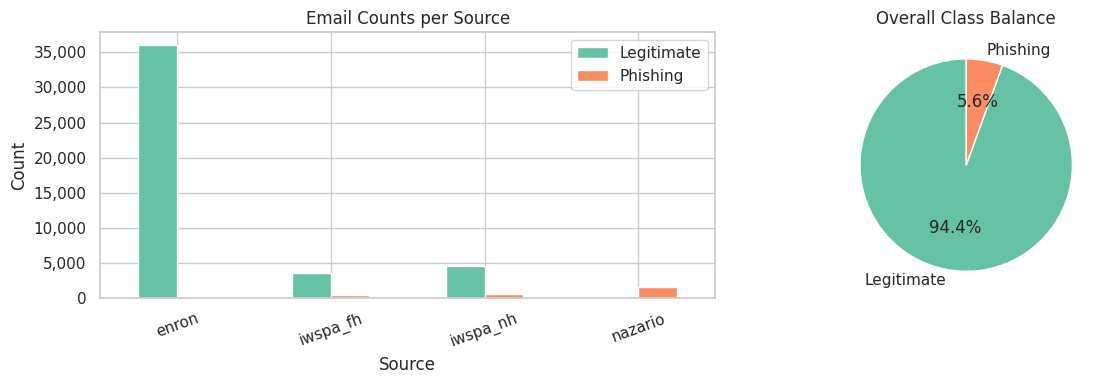

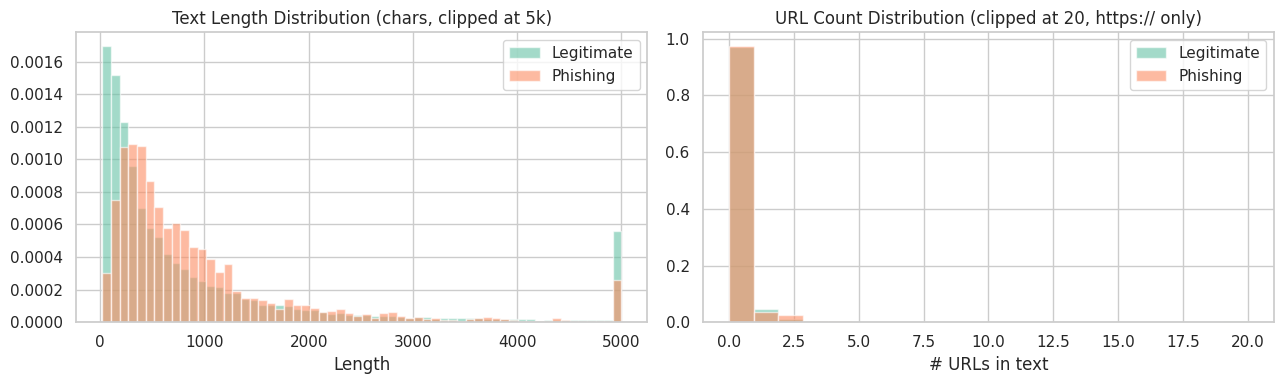

            pct_has_header  pct_has_html  avg_text_len  avg_url_count
label                                                                
Legitimate           0.896         0.222      1330.201          0.298
Phishing             0.169         0.163      3150.434          0.189


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
LABEL_NAMES = {0: "Legitimate", 1: "Phishing"}

# ── 5.1  Distribucija klasa ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Stubičasti grafikon: broj po izvoru i oznaci
pivot = df_all.groupby(["source", "label"]).size().unstack(fill_value=0)
pivot.columns = [LABEL_NAMES[c] for c in pivot.columns]
pivot.plot(kind="bar", ax=axes[0], rot=20)
axes[0].set_title("Email Counts per Source")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Tortni grafikon: ukupna ravnoteža klasa
counts = df_all["label"].value_counts()
axes[1].pie(counts, labels=[LABEL_NAMES[i] for i in counts.index],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Overall Class Balance")

plt.tight_layout()
plt.savefig(PROC_DIR / "eda_class_distribution.png", dpi=150)
plt.show()

# ── 5.2  Distribucija dužine teksta ───────────────────────────────────────────
df_all["text_len"] = df_all["text"].str.len()

# Koristimo zasebnu EDA kolonu kako bismo izbegli prepisivanje url_count iz inženjeringa karakteristika
# (Sekcija 6 broji i prave https:// URL-ove I IWSPA <<link>> oznake).
df_all["eda_url_count"] = df_all["text"].str.count(r"https?://")

# Proveravamo body_raw (pre čišćenja) za HTML — body_clean je već očišćen pa je uvek False
df_all["has_html_flag"] = df_all["body_raw"].fillna("").str.contains(
    r"<[a-zA-Z][^>]*>", regex=True).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for lbl, grp in df_all.groupby("label"):
    axes[0].hist(grp["text_len"].clip(upper=5000), bins=60, alpha=0.6,
                 label=LABEL_NAMES[lbl], density=True)
axes[0].set_title("Text Length Distribution (chars, clipped at 5k)")
axes[0].set_xlabel("Length")
axes[0].legend()

for lbl, grp in df_all.groupby("label"):
    axes[1].hist(grp["eda_url_count"].clip(upper=20), bins=21, alpha=0.6,
                 label=LABEL_NAMES[lbl], density=True)
axes[1].set_title("URL Count Distribution (clipped at 20, https:// only)")
axes[1].set_xlabel("# URLs in text")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROC_DIR / "eda_length_urls.png", dpi=150)
plt.show()

# ── 5.3  Dostupnost zaglavlja i prisustvo HTML-a ───────────────────────────────
agg = df_all.groupby("label").agg(
    pct_has_header=("has_header", "mean"),
    pct_has_html  =("has_html_flag", "mean"),
    avg_text_len  =("text_len", "mean"),
    avg_url_count =("eda_url_count", "mean"),
).rename(index=LABEL_NAMES).round(3)
print(agg.to_string())

---
## Sekcija 6 — Inženjering karakteristika

Ekstrakcija **bihevioralnih / karakteristika zasnovanih na nameri** za klasične ML modele.  
Karakteristike se računaju iz `body_clean` i `text_norm`; `text_norm` (bez artefakata) je rezervisan i za TF-IDF.

| Karakteristika | Opis |
|---|---|
| `text_len` | Ukupna dužina u karakterima — zadržana kao slab signal (phishing e-mailovi su skloni opširnosti) |
| `explicit_link_count` | Broj `<URL>` tokena u `text_norm` — obuhvata https:// linkove, IWSPA `<<link>>` oznake i sve uglaste URL tokene nastale normalizacijom; neutralan prema skupovima podataka |
| `implicit_link_signal` | Binarna zastavica: 1 ako su prisutne phishing fraze sa pozivom na link (*"visit below"*, *"access here"*, *"go to the portal"*, *"use the button below"*) čak i kada nema eksplicitnog URL-a |
| `unique_word_ratio` | Raznovrsnost vokabulara (jedinstvene reči / ukupno reči) — phishing šabloni su repetitivni |
| `urgency_count` | Phishing termini pretnje: *urgent, suspended, expired, deadline, act now, final notice* … |
| `account_count` | Termini manipulacije nalogom: *verify, confirm, login, password, credentials, suspicious activity* … |
| `cta_count` | Fraze poziva na akciju: *click here, follow the link, verify now, sign in now* … |
| `threat_action_combo` | **Interakciona karakteristika** — binarno 1 kada se i signal pretnje/hitnosti I poziv na akciju pojavljuju u istom e-mailu. Klasičan phishing obrazac: *"Vaš nalog je suspendovan → kliknite ovde da ga povratite."* |

> **Uklonjene karakteristike (sa obrazloženjem):**  
> `url_count` (nepouzdan — IWSPA unapred zamenjuje URL-ove, čineći phishing siromašnijim u URL-ovima) · `dollar_count` (Enron finansijski e-mailovi povećavaju vrednost za legitimnu klasu) · `question_count` (Enron diskusioni nizovi dominiraju) · `caps_ratio` (artefakt korporativnog formatiranja) · `word_count` / `avg_word_len` (nizak MI, stilski signal, a ne signal namere) · `has_html` / `exclamation_count` (MI ≈ 0)

TF-IDF vektori se fituju **samo na `text_norm`** (samo na skupu za obuku) kako bi se sprečilo i curenje podataka i curenje izvora.

In [ ]:
def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    t        = df["text"]
    body_cl  = df["body_clean"].fillna("")
    # text_norm sadrži naše <URL>/<EMAIL>/<PHONE>/<YEAR> tokene — koristi se za
    # explicit_link_count kako bi broj bio neutralan prema skupu podataka (https://, <<link>>,
    # i svi URL tokeni u ugaonim zagradama su kolapsovani u jedan <URL> marker).
    t_norm   = df["text_norm"].fillna("")

    # ── text_len ───────────────────────────────────────────────────────────────
    df["text_len"] = t.str.len()

    # ── Raznovrsnost vokabulara ──────────────────────────────────────────────────
    def _unique_word_ratio(s: str) -> float:
        words = s.split()
        return len(set(words)) / len(words) if words else 0.0

    df["unique_word_ratio"] = t.apply(_unique_word_ratio)

    # ── Karakteristike prisustva linkova ───────────────────────────────────────
    # explicit_link_count: broji <URL> tokene u text_norm.
    # normalize_text() objedinjuje sve: https:// URL-ove, IWSPA <<link>> oznake,
    # i URL tokene u ugaonim zagradama u jedan "<URL>" marker, pa je ovaj broj
    # stabilan i neutralan prema skupu podataka.
    df["explicit_link_count"] = t_norm.str.count("<URL>")

    # implicit_link_signal: binarna zastavica za phishing fraze koje pozivaju na praćenje linka,
    # koje impliciraju "prati link" čak i kada nema eksplicitnog URL-a.
    # Namerno odvojeno od cta_count ("click here") radi hvatanja mekših oblika.
    _IMPLICIT_LINK_RE = re.compile(
        r"\b(visit\s+(below|here|us|our|the\s+(link|page|site|url))|"
        r"access\s+(here|below|the\s+(link|page|account|portal))|"
        r"go\s+to\s+(the\s+)?(link|page|site|portal|url)|"
        r"use\s+the\s+(link|url|button)\s+below|"
        r"follow\s+the\s+(link|url|instructions)\s+below|"
        r"tap\s+(here|the\s+link|below))\b",
        re.IGNORECASE,
    )
    df["implicit_link_signal"] = body_cl.apply(
        lambda s: int(bool(_IMPLICIT_LINK_RE.search(s)))
    )

    # ── Bihevioralni signali phishinga ─────────────────────────────────────────
    _URGENCY_RE = re.compile(
        r"\b(urgent|urgently|immediately|action\s+required|suspended|"
        r"locked\s+out|your\s+account\s+(has\s+been|is|will\s+be)|"
        r"expire[sd]?|expiration|deadline|attention|alert|warning|"
        r"act\s+now|final\s+notice|last\s+chance)\b",
        re.IGNORECASE,
    )
    _ACCOUNT_RE = re.compile(
        r"\b(verify|verification|confirm(?:ation)?|update\s+your|"
        r"log\s*in|login|password|credentials|secure\s+your|"
        r"security\s+alert|authenticate|suspicious\s+(activity|login|access)|"
        r"account\s+(verify|confirm|update|suspend|access|number))\b",
        re.IGNORECASE,
    )
    _CTA_RE = re.compile(
        r"\b(click\s+here|click\s+below|click\s+the\s+link|follow\s+the\s+link|"
        r"confirm\s+your\s+identity|verify\s+now|verify\s+your|"
        r"sign\s+in\s+now|log\s+in\s+now|open\s+the\s+link)\b",
        re.IGNORECASE,
    )

    df["urgency_count"] = body_cl.apply(lambda s: len(_URGENCY_RE.findall(s)))
    df["account_count"] = body_cl.apply(lambda s: len(_ACCOUNT_RE.findall(s)))
    df["cta_count"]     = body_cl.apply(lambda s: len(_CTA_RE.findall(s)))

    # ── Interakciona karakteristika ──────────────────────────────────────────────
    # threat_action_combo: 1 kada se I signal pretnje/hitnosti I CTA pojavljuju zajedno.
    # Klasični phishing obrazac: "Vaš nalog je suspendovan → kliknite ovde da ga povratite."
    df["threat_action_combo"] = (
        ((df["urgency_count"] > 0) | (df["account_count"] > 0)) &
        (df["cta_count"] > 0)
    ).astype(int)

    return df


print("Extracting features ...")
df_all = extract_features(df_all)

FEATURE_COLS = [
    "text_len",
    "explicit_link_count",
    "implicit_link_signal",
    "unique_word_ratio",
    "urgency_count",
    "account_count",
    "cta_count",
    "threat_action_combo",
]

print(df_all[FEATURE_COLS + ["label"]].groupby("label").mean()
      .rename(index=LABEL_NAMES).round(3).to_string())

Extracting features ...
            text_len  explicit_link_count  implicit_link_signal  unique_word_ratio  urgency_count  account_count  cta_count  threat_action_combo
label                                                                                                                                           
Legitimate  1330.201                0.365                 0.010              0.782          0.136          0.107      0.060                0.010
Phishing    3150.434                0.263                 0.083              0.660          0.766          2.180      0.718                0.274


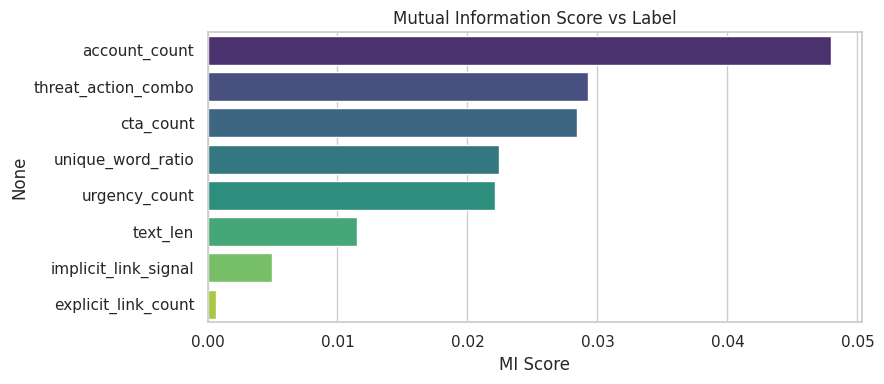

account_count           0.047954
threat_action_combo     0.029287
cta_count               0.028463
unique_word_ratio       0.022408
urgency_count           0.022126
text_len                0.011515
implicit_link_signal    0.004996
explicit_link_count     0.000618


In [27]:
from sklearn.feature_selection import mutual_info_classif

X_feat = df_all[FEATURE_COLS].fillna(0).values
y      = df_all["label"].values

mi_scores = mutual_info_classif(X_feat, y, random_state=42)
mi_df = pd.Series(mi_scores, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=mi_df.values, y=mi_df.index, palette="viridis")
plt.title("Mutual Information Score vs Label")
plt.xlabel("MI Score")
plt.tight_layout()
plt.savefig(PROC_DIR / "feature_importance_mi.png", dpi=150)
plt.show()
print(mi_df.to_string())